# Overview
In a perfect world with perfect data, data scientists would spend all their time doing science with data. In reality, much of our time is spent *preparing* data so that we can eventually do the science part. These preparation, or cleaning steps, are necessary because datasets frequently contain messy or missing data. This lecture will cover some common practices for data preparation and cleaning. This will include:
- Introduction to Numpy
- Brief review of statistics
- Visual tools for data cleaning
- NaN handling: null labels, dropping vs imputing, imputation methods
- Noise reduction: moving average, median filtering (1D, 2D)
- If there is time: Type consistency and casting

# Numpy
Numpy is a Python package that we will use to store data and do math with that data more efficiently. We've already been introduced to numpy through `pandas`, because under the hood the values stored in a pandas DataFrame are numpy arrays. Here, we will introduce them a bit more rigorously. 

## Basics of Numpy arrays

In [4]:
import numpy as np

The base `numpy` data type is the n-dimensional array. In a lot of ways, it behaves exactly like a list, and you can even initialize one from a list:

In [5]:
example_list = [1, 2, 3, 4, 5]
example_array = np.array(example_list)

We can slice and extract data from a numpy array just like a list:

In [6]:
example_array[0]

np.int64(1)

In [7]:
example_array[-2:]

array([4, 5])

And we can apply Boolean logic to arrays just like we do on `pandas` Series objects:

In [8]:
example_array < 3

array([ True,  True, False, False, False])

This helps us extract portions of arrays based on logical conditions:

In [6]:
example_array[example_array < 3]

array([1, 2])

Numpy handles NaN values using its built-in `np.nan` type. Here we can "nan-out" particular values in the array:

In [7]:
example_array[(example_array % 2 == 0)] = np.nan

ValueError: cannot convert float NaN to integer

Whoops! that didn't quite work because of a type mismatch. The array was initialized with integer values, and we tried to replace some values with `np.nan`, which is a float. One of the situations where the difference matters.

In [8]:
example_array = np.array(example_list, dtype=np.float64) # Could also do example_array = example_array.astype(float)

In [9]:
example_array[(example_array % 2 == 0)] = np.nan

In [10]:
example_array

array([ 1., nan,  3., nan,  5.])

Numpy arrays can also be multi-dimensional, like a DataFrame that has values along the rows and columns. We call this a matrix:

In [12]:
example_matrix = np.random.rand(3, 3)  # Initialize a random 3 x 3 matrix

In [13]:
example_matrix

array([[0.62285984, 0.9664753 , 0.1133076 ],
       [0.53198885, 0.16494134, 0.00439383],
       [0.50576385, 0.5050617 , 0.59979037]])

We can extract row and column values in a similar way to the 1d case:

In [16]:
col_1 = example_matrix[:, 0]
col_1

array([0.62285984, 0.53198885, 0.50576385])

In [17]:
row_1 = example_matrix[0, :]
row_1

array([0.62285984, 0.9664753 , 0.1133076 ])

In [18]:
last_element = example_matrix[2, 2]
last_element

np.float64(0.5997903676047605)

## Initialization shortcuts

If you want an array of linearly spaced values between two endpoints:

In [ ]:
np.linspace(0.1, 1, 10)

If you want an array of values with a certain spacing between them:

In [11]:
np.arange(1, 10, 0.5)

array([1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5, 7. ,
       7.5, 8. , 8.5, 9. , 9.5])

If you want an array full of zeros or ones of a certain shape:

In [19]:
np.zeros((3, 3))

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [20]:
np.ones((5,))

array([1., 1., 1., 1., 1.])

Or an array of NaN:

In [21]:
np.zeros((5, 2)) * np.nan

array([[nan, nan],
       [nan, nan],
       [nan, nan],
       [nan, nan],
       [nan, nan]])

## Math with arrays
The real power of numpy arrays is the math that it lets us do. We'll learn about all the linear algebra operations next lecture, but for now the most important thing to understand are the elementwise operations that lists don't allow.

This isn't math, it's concatenation:

In [1]:
a_list = [1, 2, 3]
b_list = [4, 5, 6]
a_list + b_list

[1, 2, 3, 4, 5, 6]

And this doesn't even work:

In [2]:
a_list * b_list

TypeError: can't multiply sequence by non-int of type 'list'

Nor this:

In [ ]:
a_list ** 2

But with a numpy array we can do elementwise math:

In [15]:
a_array = np.array([1, 2, 3])
b_array = np.array([4, 5, 6])
a_array + b_array

array([5, 7, 9])

In [16]:
a_array * b_array

array([ 4, 10, 18])

In [17]:
a_array ** 2

array([1, 4, 9])

In [18]:
b_array + 5

array([ 9, 10, 11])

In [19]:
2 * b_array

array([ 8, 10, 12])

# Quick Breakout: Numpy Practice
1. Create a numpy array `x` that contains 100 values evenly spaced between 10 and 20
2. Create another numpy array `y`, where each element $y_i$ is given by $y_i = 2 x_i + 5$ for $i = 1, \dots, 100$.
3. Use matplotlib to plot $x$ vs $y$

In [29]:
x = np.linspace(10, 20, 100)
x
print(type(x))

<class 'numpy.ndarray'>


In [32]:
y = np.array([((2 * x_i) + 5) for x_i in x])
print(type(y))
print(y.shape)

<class 'numpy.ndarray'>
(100,)


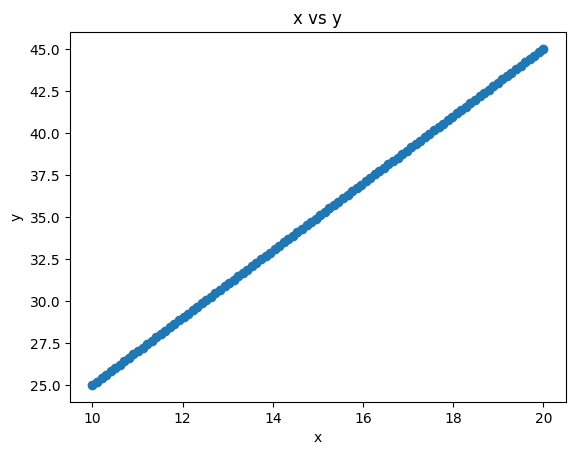

In [33]:
import matplotlib.pyplot as plt
plt.plot(x, y, 'o')
plt.xlabel("x")
plt.ylabel("y")
plt.title("x vs y")
plt.show()

# Stats Review
In data science we often want to determine the probability that a certain data point (or group of data points) in a dataset are real (i.e., to be trusted), vs noise (not to be trusted). Noisy data can have many sources. For example, bad sensors, bad data entry, wrong units, and general upstream bugs in data processing can all negatively impact data quality, and it is often our job to identify *when* that is the case. Statistics can help answer the question: how likely (or unlikely) is it to observe a particular outcome? Here we will review some basic statistics concepts for that purpose. 

## Mean, Median, Standard Deviation

The mean value of a vector $x$ of length $n$ is defined as
$$ \overline{x} = \frac{1}{n} \sum_{i = 1}^n x_i $$
The mean is a *measure of central tendency*, meaning that it gives us an estimate of a typical value of a dataset. 

In [ ]:
x = np.array([1, 2, 3, 4, 5, 100, 200])
x_bar = np.mean(x)
print(x_bar)

Another common measure of central tendency is the median, which gives us the 50th percentile value of a vector. You'll notice that the median is not as influenced by outliers as the mean is:

In [ ]:
x_med = np.median(x)
print(x_med)

While the mean and median provide typical values of a variable, the standard deviation tells us how much variability there is in the variable. In other words, how *far away from the mean* are typical values of the variable? Standard deviation is defined as
$$ \sigma = \sqrt{\frac{\sum_{i = 1}^n (x_i - \overline{x})^2}{n}},$$
though you will sometimes see $n-1$ instead of $n$ in the denominator. For a large enough sample size, this barely makes a difference.  For what it's worth, `numpy` uses $n$:

In [ ]:
x_std = np.std(x)
print(x_std)

Note: If our array contains NaN values, we can use the functions `np.nanmean`, `np.nanmedian`, and `np.nanstd` instead, which ignores NaN values when calculating the statistics. 

## Probability density functions
A dataset can be roughly summarized with statistics like the mean, median, and standard deviation. But a much more holistic view can be obtained by the probability density function for a variable or a process. 

A function $f(x)$ is considered a probability density function if:
- $f(x) \geq 0$ over the function's support
- $\int_{-\infty}^{\infty} f(x)\text{d}x = 1$
- $\int_{a}^{b} f(x) \text{d}x = P(a \leq x \leq b)$

That final bullet point is the most important, and says: the probability that $x$ is between $a$ and $b$ is given by the integral of the probability density function between $a$ and $b$.

The takeaway is that if we know the probability density function for a certain event or process, we are in good shape because we can calculate probabilities based on it via integration. 

We can also calculate statistics like the mean, median, and standard deviation from a PDF. The mean $\mu$ is defined as:
$$ \mu = \int_{-\infty}^{\infty} x f(x) dx$$

And the median $\tilde{\mu}$ is given by:
$$\tilde{\mu} = \int_{-\infty}^{\tilde{\mu}} f(x) dx = 0.5$$

And the standard deviation $\sigma$:
$$\sigma = \sqrt{\int_{-\infty}^{\infty} (x - \mu)^2 f(x) dx}$$

Though in practice, the integration bounds may be finite and restricted to the domain of the specific PDF you are integrating. 

## Probability distributions
In general, we won't know the probability density function for whatever we are interested in. But there are certain general *probability distributions* that statisticians have found are widely applicable to a range of problems. We'll talk about a couple of the most common ones.

### Normal Distribution
The normal (or Gaussian) distribution is described by
$$ f(x) = \frac{1}{\sqrt{2\pi} \sigma} \exp\left(-\frac{(x - \mu)^2}{2 \sigma^2}\right) $$
where $\mu$ is the mean of the distribution and $\sigma$ is the standard deviation. We can plot this in python:

Text(0, 0.5, 'Density')

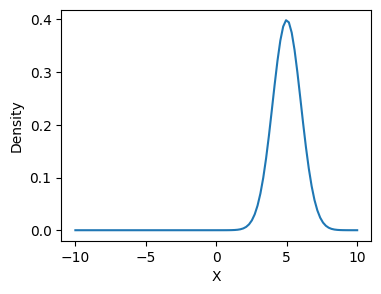

In [35]:
import matplotlib.pyplot as plt
x = np.linspace(-10, 10, 100)
mu = 5
sigma = 1
density = np.exp(-(x - mu)**2 / (2 * sigma**2)) / np.sqrt(2 * np.pi * sigma)
plt.figure(figsize=(4, 3))
plt.plot(x, density)
plt.xlabel("X")
plt.ylabel("Density")

### Quick breakout: try changing the mean and standard deviation of the distribution, $\mu$ and $\sigma$. How does this affect the distribution?

What the plots of the normal distribution tell us is that values around the mean $\mu$ are the most common, because there is more area under the curve around that value. Compare that to $x = -10$ (for $\mu = 3$), there is effectively zero area under the curve, so if a variable in our dataset was described by this distribution and we saw a value of $-10$, that would be highly suspect. However, if we increased the standard deviation significantly, then the density would spread out, and values far from the mean would become increasingly likely. 

There are some simple rules of thumb that you should memorize for a normal distribution:
- 68% of the area under the curve is within 1 standard deviation of the mean
- 95% of the area under the curve is within 2 standard deviations of the mean
- 99.7% of the area under the curve is within 3 standard deviations of the mean

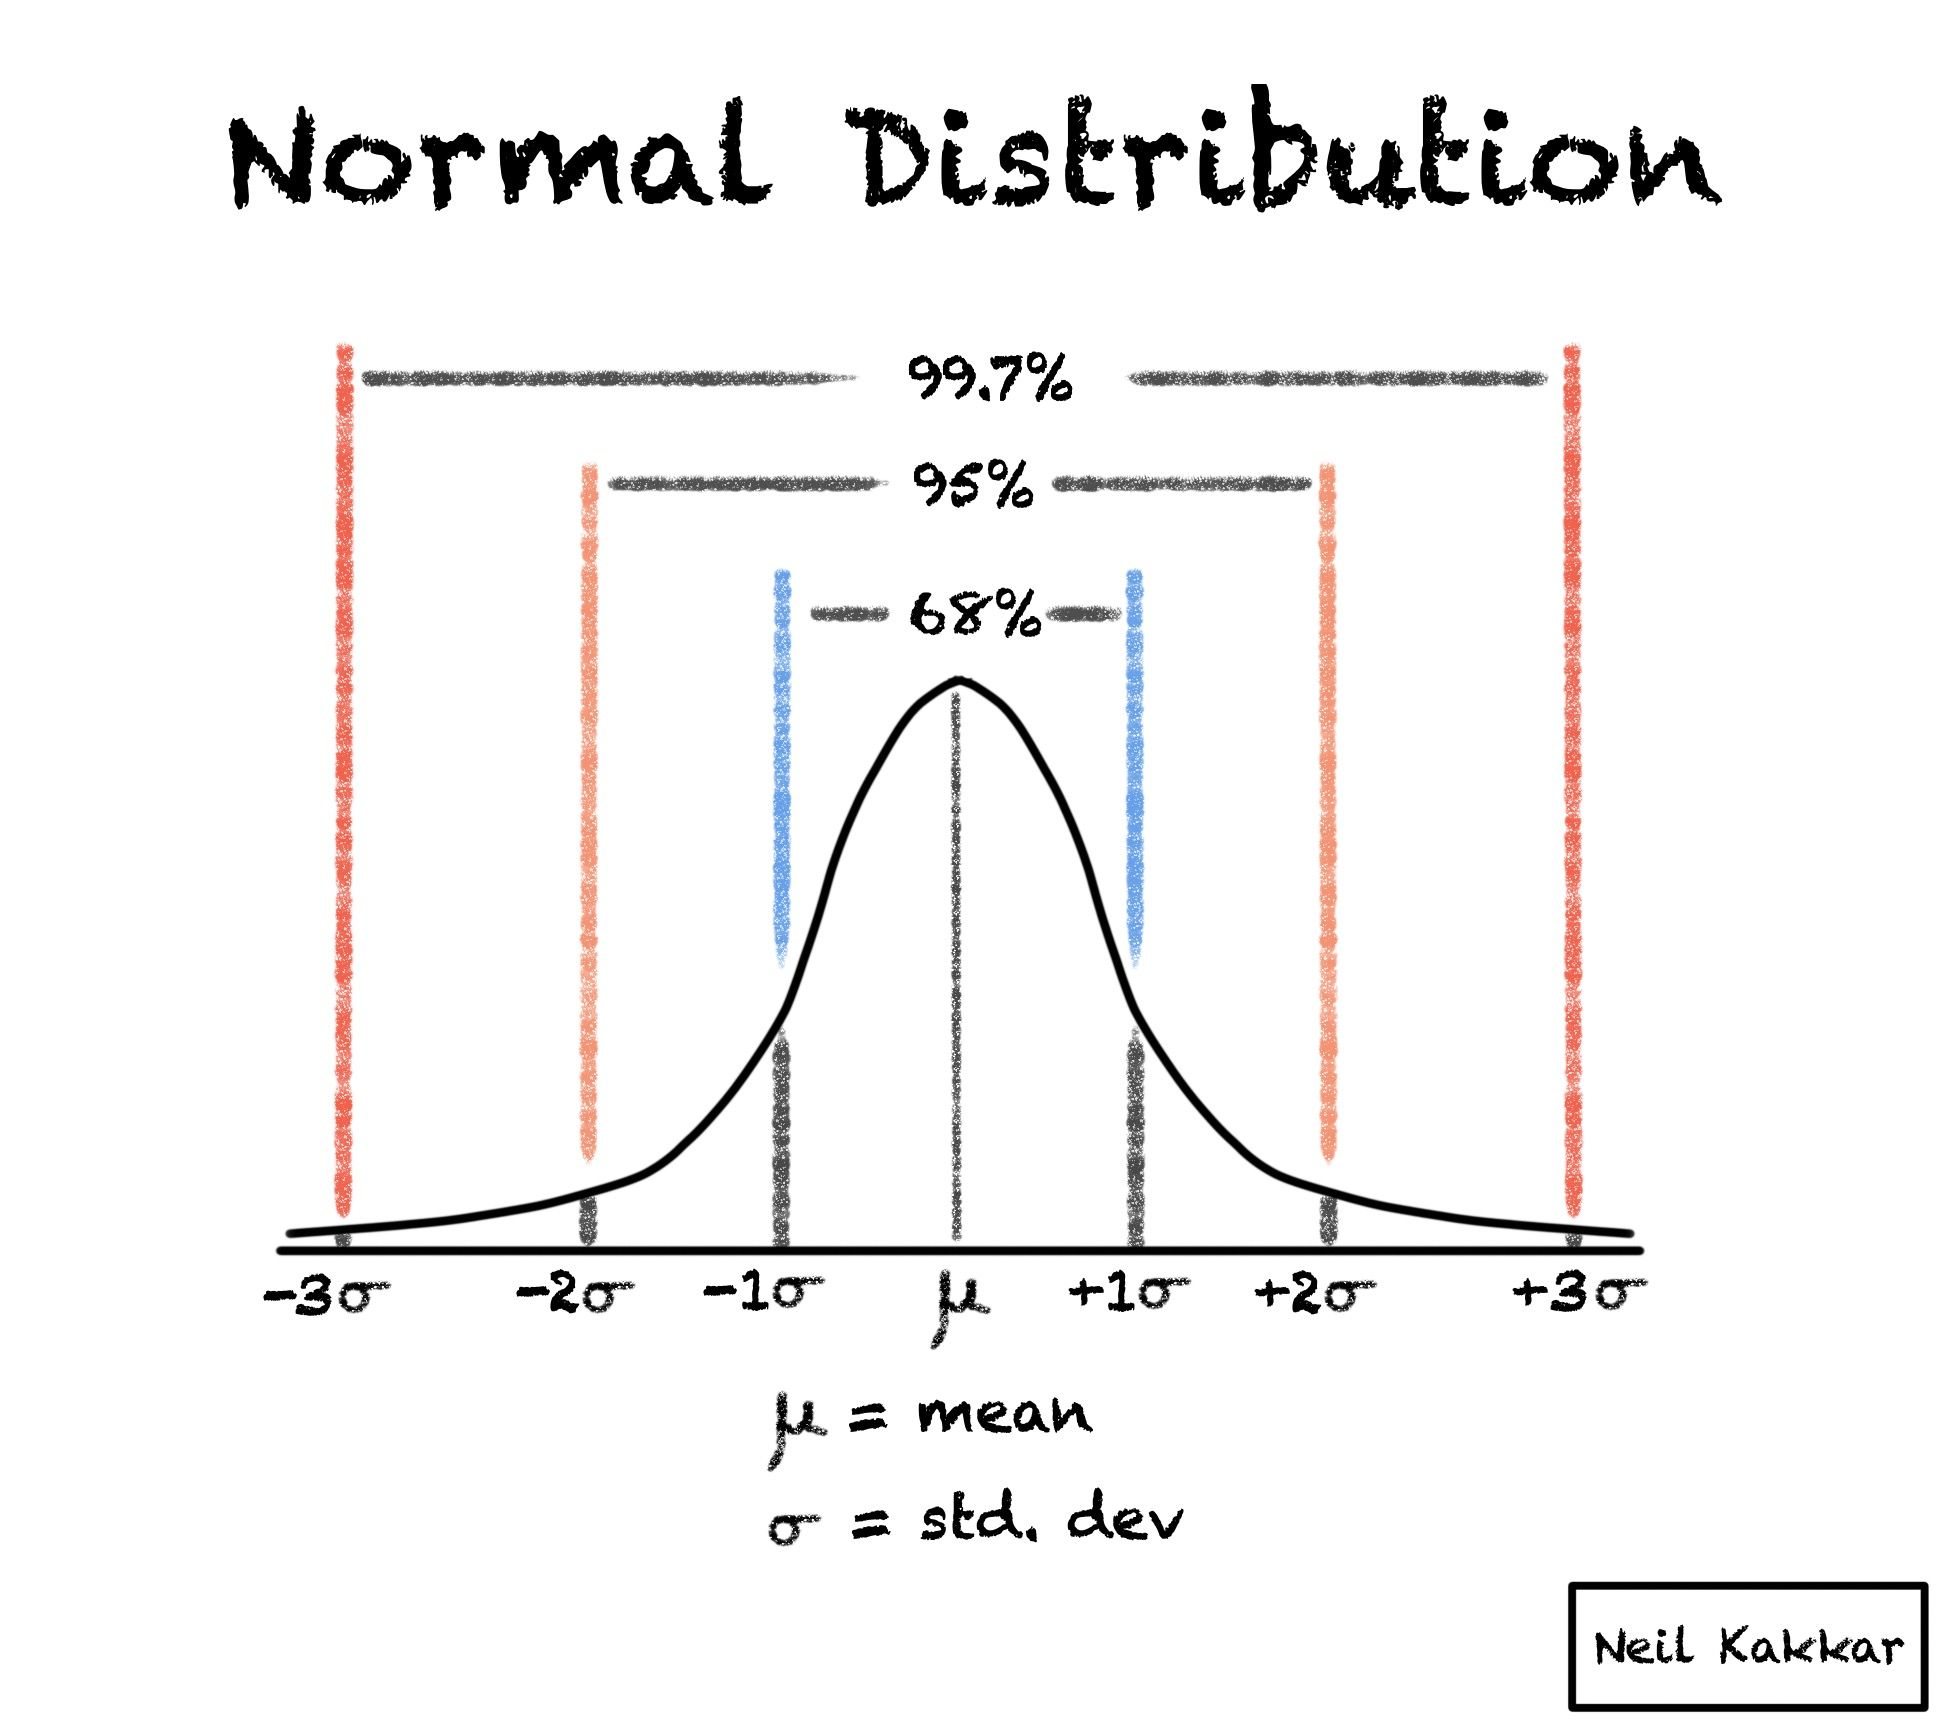

In [36]:
from PIL import Image
Image.open("../img/normal_dist_rule.jpg")

How do we know if a normal distribution is appropriate to use for our data? Usually, we just make a histogram and see how normal it looks. Let's look at a long-term oceanographic dataset from the north pacific to see what the distributions look like for different variables

In [37]:
import pandas as pd
df = pd.read_csv("https://github.com/galenegan/DATA-3320/raw/main/climate/north_pacific.csv")
df = df.rename(columns={"sst": "sea_surface_temperature", "u10": "wind_velocity", "hsig": "wave_height"})

array([[<Axes: title={'center': 'sea_surface_temperature'}>,
        <Axes: title={'center': 'wind_velocity'}>],
       [<Axes: title={'center': 'wave_height'}>, <Axes: >]], dtype=object)

<Figure size 640x480 with 0 Axes>

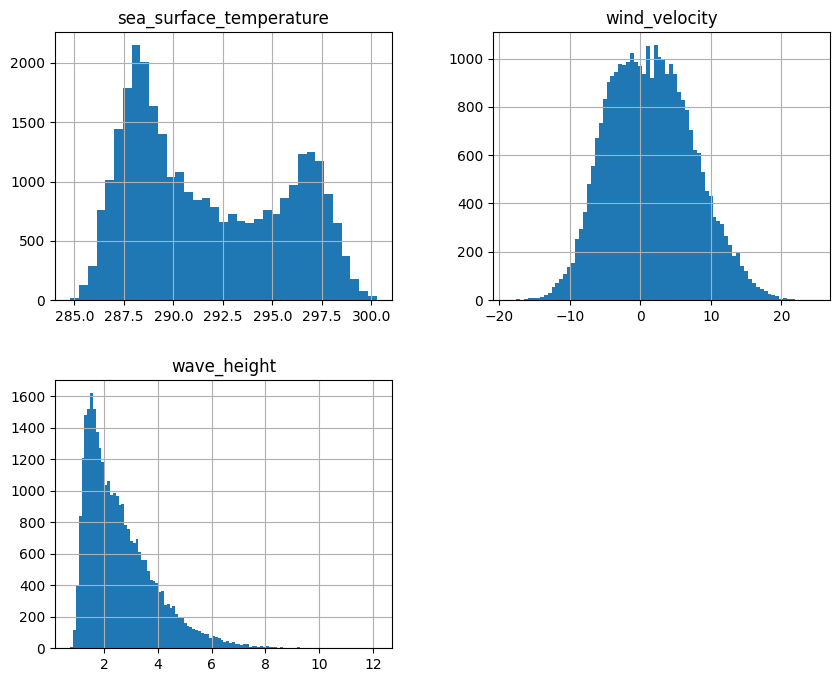

In [38]:
fig = plt.figure()
df.hist(column=["sea_surface_temperature", "wind_velocity", "wave_height"], bins="auto", figsize=(10,8))

How would we categorize each of the variables?
- Sea surface temperature: bimodal (why?). Subsets may be normal
- Wind velocity: pretty normal, slightly skewed
- wave height: not normal, right-skewed, seems to be clamped at zero

Because wind velocity is approximately Gaussian, we can use the properties of the normal distribution to classify different ranges of values. For example, if someone asked you to identify the range of wind velocity that you might encounter 95% of the time, you could simply do:

In [ ]:
wind_range_lower_bound = df["wind_velocity"].mean() - 2 * df["wind_velocity"].std()
wind_range_upper_bound = df["wind_velocity"].mean() + 2 * df["wind_velocity"].std()
(wind_range_lower_bound, wind_range_upper_bound)

# Visual tools for outlier detection

Let's say someone hands you a dataset and tells you to clean it up by getting rid of suspicious outlier values. We'll use a subset of the [UCI Wine Dataset](https://archive.ics.uci.edu/dataset/109/wine) as an example. Contained in the data are the alcohol and proline contents of 2 different types of wine. However, data from a third and pretty different type snuck in as well, and we want to identify which data points are from that third variety. 

In [39]:
df_full = pd.read_csv("../data/wine.csv")
df = df_full.drop(columns=["outlier"])

The best way to start is with a pairplot:

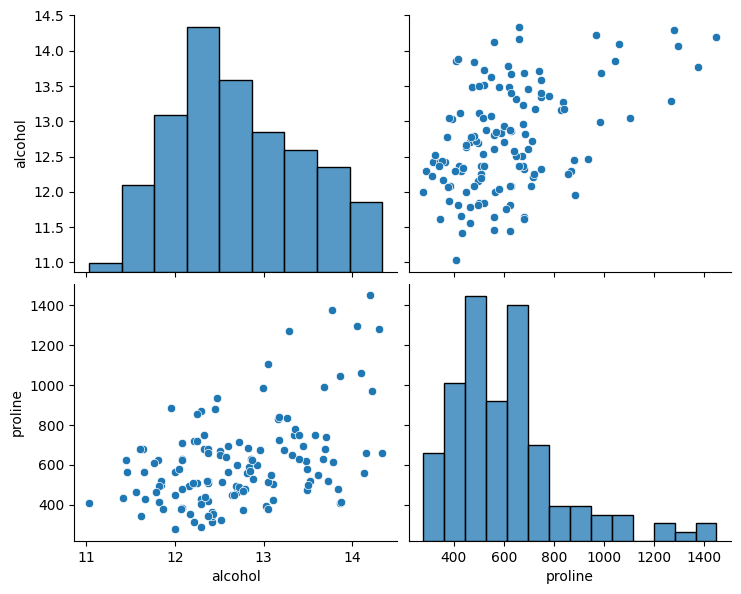

In [40]:
import seaborn as sns
fig = sns.pairplot(df, height=3, aspect=1.25)

Do any clumps of data points look like they might not fit in with the rest? 

Values where proline and alcohol are higher

Let's check by highlighting the outlier values from the full dataframe:

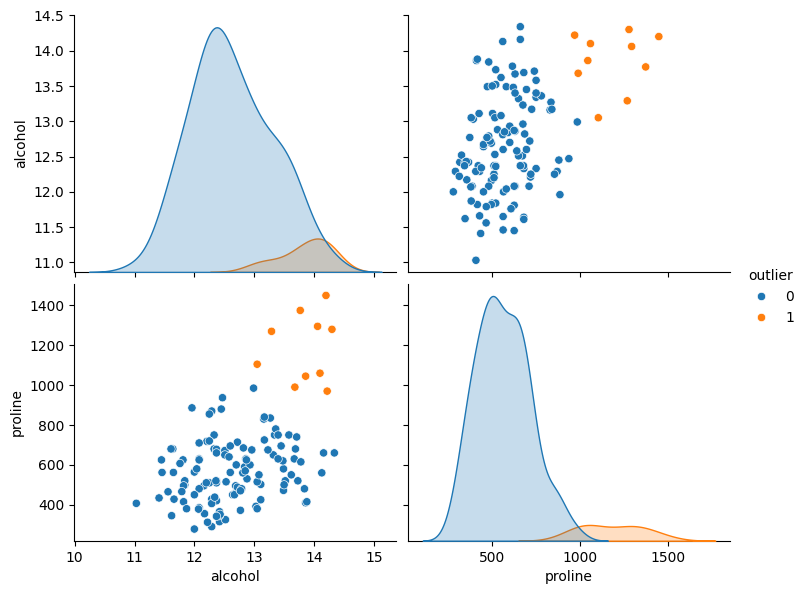

In [41]:
fig = sns.pairplot(df_full, hue="outlier", height=3, aspect=1.25)

So it was indeed the high alcohol + high proline wines that didn't belong. Let's see if we could have done a similar outlier identification by normalizing the proline data and excluding values outside a certain number of standard deviations from the mean. 

Here, we use a common trick to make right-skewed data look more Normal: take its natural logarithm

(array([ 4.,  8., 15., 19., 22., 28., 14.,  7.,  6.,  1.,  5.]),
 array([5.62762111, 5.77777545, 5.92792979, 6.07808413, 6.22823847,
        6.37839281, 6.52854714, 6.67870148, 6.82885582, 6.97901016,
        7.1291645 , 7.27931884]),
 <BarContainer object of 11 artists>)

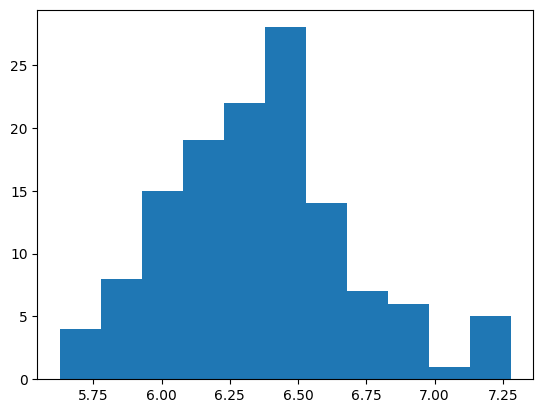

In [42]:
df["log_proline"] = np.log(df["proline"])
plt.hist(df["log_proline"], bins="auto")

In [43]:
n_std_cutoff = 1.5
upper_bound = df["log_proline"].mean() + n_std_cutoff * df["log_proline"].std()

In [44]:
upper_bound

np.float64(6.863112158825157)

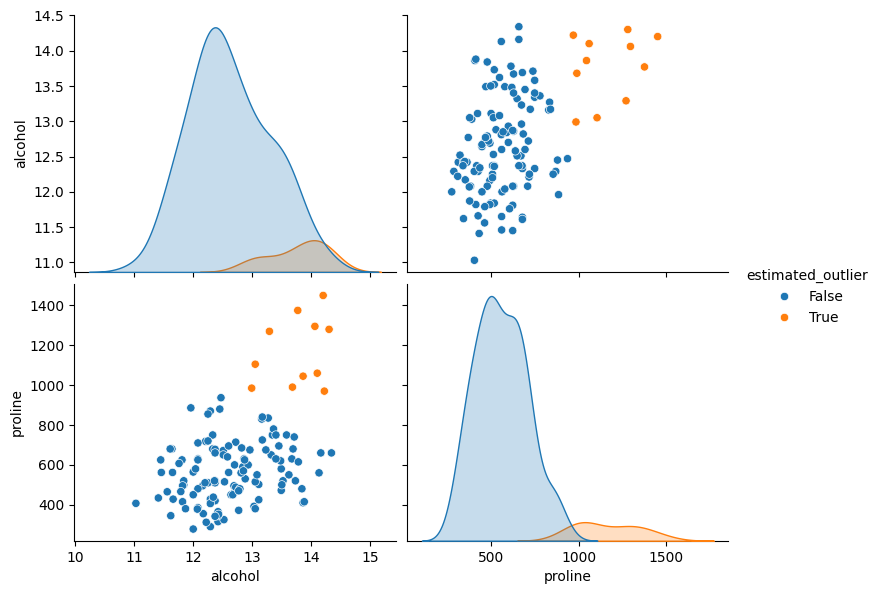

In [45]:
df["estimated_outlier"] = (df["log_proline"] >= upper_bound)
fig = sns.pairplot(df, vars=["alcohol", "proline"], hue="estimated_outlier", height=3, aspect=1.25)

# NaN Handling
Sometimes, for whatever reason, individual data points will be missing. They are usually filled in with some variation of `NaN`, which stands for `Not A Number`, and is an example of a [sentinel value](https://en.wikipedia.org/wiki/Sentinel_value). When we encounter NaN values, we have choices to make about how to handle them in our analysis. And when we are creating a dataset, we have choices to make about how to label NaN values. We'll start with that first. 

## Proper labeling
There is no single right way to label a `NaN` value, because the right way varies by situation. But here are some general guidelines you can follow.
- If you need to label missing values in a numpy array or Pandas dataframe, `np.nan` is a good approach. For example, `df.loc[bad_indices, "column_name"] = np.nan`
- If you are labeling missing values in a Python dictionary or json blob that could potentialy end up on the internet or get passed through an internal API, then Python's built-in `None` is the best option. This is because the json format can't handle `np.nan`, but `None` will automatically get converted to the Java `null`.
- If you are restricted to using numeric values and cannot label something `NaN` or `None`, then it is ok to define a numeric sentinel value, ideally something very obviously out-of-place in the dataset. Using something like `-999` or `-1` for variables that are always nonnegative is common.
- As an example of what not to do: I once had to deal with data from a customer who labeled `NaN` data for vessel bearing (the direction a vessel is traveling) as `bearing = 0`. This is *insane*, because a bearing of 0 degrees conventionally means that you are heading north. Confusion ensued! Accusations were made! Relationships soured! And all because of improper NaN labeling.

## Can I just drop NaN values?
It is often tempting to just drop any rows of a dataset where one or more of the features is NaN. This can be ok if:
- Your dataset is large enough already, and dropping the NaN rows won't reduce its size by more than a few %
- The data that you are dropping isn't special in some way. In other words, the other features (that aren't NaN) have a similar distribution both within and outside of the dropped portion.

But if, by dropping NaNs, you are getting rid of a significant portion of your data, then you should probably try to impute those missing values. 

## Imputation
Imputation refers to the process of replacing a `NaN` value in a dataset with an educated guess for a real value that might take its place. We'll learn about a couple ways to do this. 

### Interpolation
Interpolation involves filling in data gaps by using data that came from before and after the gap. Let's go back to our sea surface temperature data and see an example:

In [46]:
df = pd.read_csv("https://github.com/galenegan/DATA-3320/raw/main/climate/north_pacific.csv")
df = df.rename(columns={"sst": "sea_surface_temperature", "u10": "wind_speed", "hsig": "wave_height"})
sst = df.loc[:100, "sea_surface_temperature"]

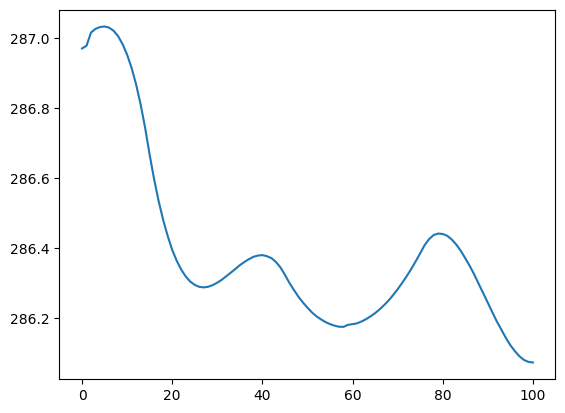

In [47]:
import matplotlib.pyplot as plt
plt.plot(sst)

Now let's replace a bunch of random values with NaN:

In [50]:
nan_pct = 0.2 
N = len(sst)
index_to_nan = np.random.choice(np.arange(N), int(nan_pct * N))
sst

0      286.97070
1      286.97836
2      287.01630
3      287.02680
4      287.03183
         ...    
96     286.10530
97     286.09094
98     286.08044
99     286.07474
100    286.07306
Name: sea_surface_temperature, Length: 101, dtype: float64

In [51]:
sst[index_to_nan] = np.nan

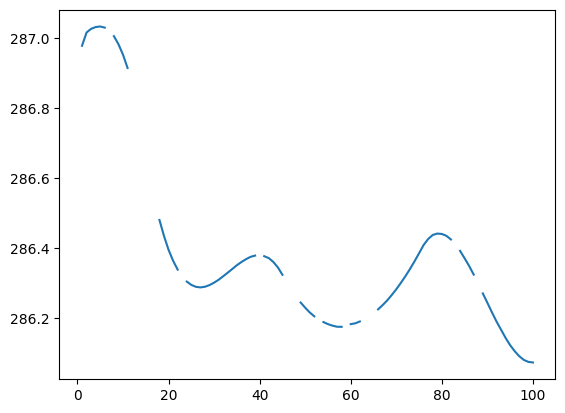

In [52]:
plt.plot(sst)

Linear Interpolation

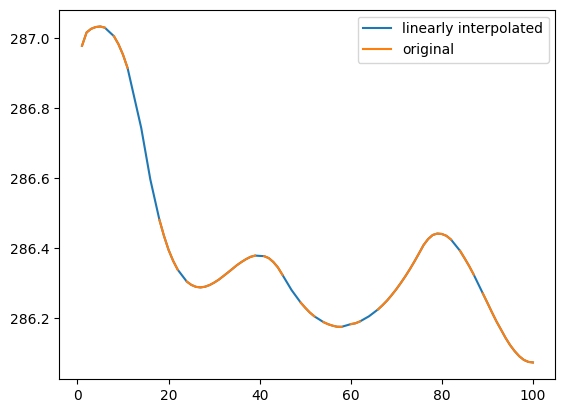

In [53]:
sst_linear_interp = sst.interpolate(method="linear")
plt.plot(sst_linear_interp, label="linearly interpolated")
plt.plot(sst, label="original")
plt.legend()

Cubic Interpolation

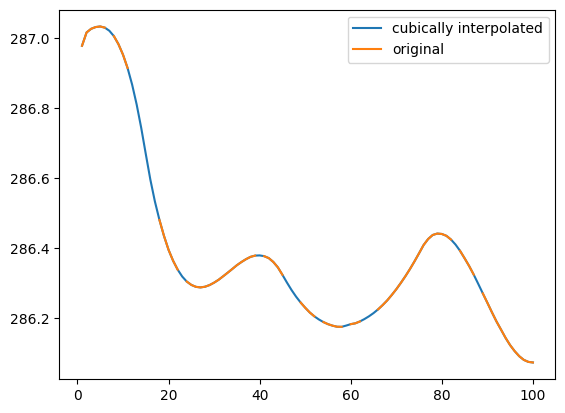

In [54]:
sst_cubic_interp = sst.interpolate(method="cubic")
plt.plot(sst_cubic_interp, label="cubically interpolated")
plt.plot(sst, label="original")
plt.legend()

Nearest Neighbor Interpolation

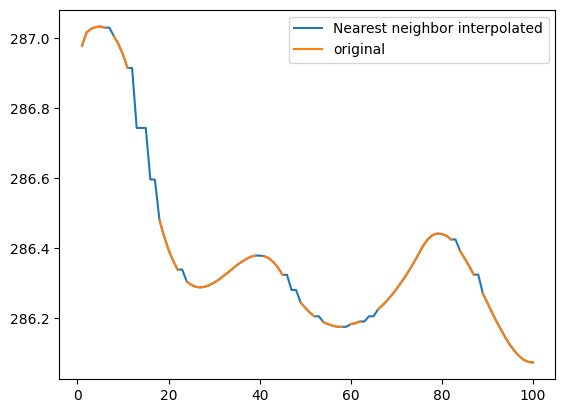

In [55]:
sst_nearest_interp = sst.interpolate(method="nearest")
plt.plot(sst_nearest_interp, label="Nearest neighbor interpolated")
plt.plot(sst, label="original")
plt.legend()

### Advanced Imputers
Sometimes you have more information available than just a single variable with gaps in it. In those cases, it can be worth using a more advanced imputation technique that takes other features in your dataset into consideration. We'll use a sample dataset to highlight this, where `x1` and `x2` are features, and `y` is the thing we are trying to predict. 

In [56]:
df = pd.DataFrame({'x1': [2.1, 3.2, 4.1, 1.15, 5.05, 6.1, 7.2, 8.1, np.nan],
                   'x2': [2.9, np.nan, -0.9, 3.3, -2.9, -2.6, -4.4, -6.4, -1.7],
                   'y': [6.45,  9.6 , 10.4 ,  5.9, 12.6 , 16.33, 18.6 , 20.3, 19.5]})

df

,x1,x2,y
0,2.10,2.9,6.45
1,3.20,NaN,9.60
2,4.10,-0.9,10.40
3,1.15,3.3,5.90
4,5.05,-2.9,12.60
5,6.10,-2.6,16.33
6,7.20,-4.4,18.60
7,8.10,-6.4,20.30
8,NaN,-1.7,19.50


Plotting the data

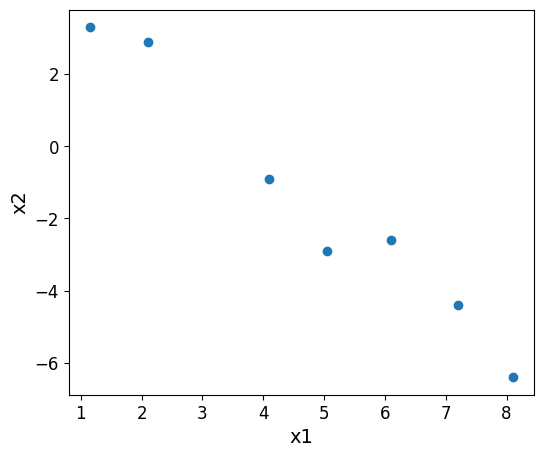

In [57]:
plt.figure(figsize = (6,5))

plt.plot(df['x1'], df['x2'], 'o')

plt.xlabel('x1', fontsize = 14)
plt.ylabel('x2', fontsize = 14)
plt.tick_params(labelsize = 12)

First we pre-process the data to remove its mean and normalize for unit variance. This is a standard step in almost all machine learning applications

In [59]:
from sklearn import preprocessing
from sklearn.impute import KNNImputer
scaler = preprocessing.StandardScaler().fit(df) # scales the data and the computes mean and std .fit() for later scaling
df_scaled = pd.DataFrame(scaler.transform(df), columns = ['x1', 'x2', 'y'])
df_scaled

,x1,x2,y
0,-1.104369,1.434131,-1.301924
1,-0.623258,NaN,-0.703035
2,-0.229621,0.219714,-0.550936
3,-1.519875,1.561965,-1.406492
4,0.185884,-0.419453,-0.132664
5,0.645127,-0.323578,0.576497
6,1.126238,-0.898829,1.008078
7,1.519875,-1.537996,1.331288
8,NaN,-0.035953,1.179189


Next we rely on the K-nearest-neighbors imputer to impute the missing values. Another good choice is the IterativeImputer, which relies on a different algorithm under the hood but has the same implementation. 

In [60]:
imputer = KNNImputer(n_neighbors=2)

In [61]:
X = df_scaled[['x1', 'x2']]

In [62]:
df_knn_scaled = df_scaled.copy()

In [63]:
df_knn_scaled[['x1', 'x2']] = imputer.fit_transform(X)

Here is our imputed dataframe in the scaled coordinates

In [64]:
df_knn_scaled

,x1,x2,y
0,-1.104369,1.434131,-1.301924
1,-0.623258,0.826922,-0.703035
2,-0.229621,0.219714,-0.550936
3,-1.519875,1.561965,-1.406492
4,0.185884,-0.419453,-0.132664
5,0.645127,-0.323578,0.576497
6,1.126238,-0.898829,1.008078
7,1.519875,-1.537996,1.331288
8,0.207753,-0.035953,1.179189


And here we do the `inverse_transform` to get the data back in its original units/coordinates

In [65]:
df_knn = pd.DataFrame(scaler.inverse_transform(df_knn_scaled), columns = ['x1', 'x2', 'y'])

In [66]:
df_knn

,x1,x2,y
0,2.10,2.9,6.45
1,3.20,1.0,9.60
2,4.10,-0.9,10.40
3,1.15,3.3,5.90
4,5.05,-2.9,12.60
5,6.10,-2.6,16.33
6,7.20,-4.4,18.60
7,8.10,-6.4,20.30
8,5.10,-1.7,19.50


We can plot it to make sure everything makes sense

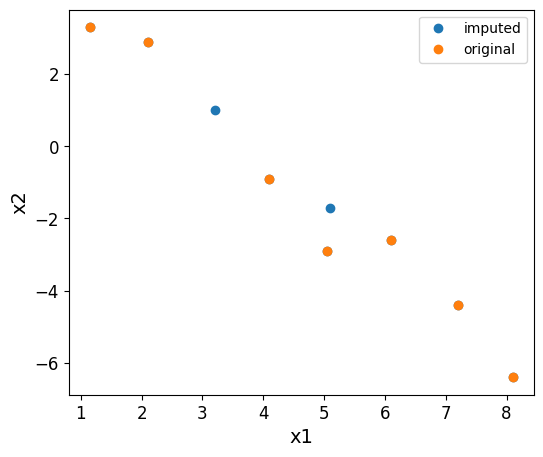

In [67]:
plt.figure(figsize = (6,5))

plt.plot(df_knn['x1'], df_knn['x2'], 'o', label = 'imputed')

plt.plot(df['x1'], df['x2'], 'o', label = 'original')

plt.xlabel('x1', fontsize = 14)
plt.ylabel('x2', fontsize = 14)
plt.legend()
plt.tick_params(labelsize = 12)

# Smoothing Techniques
Finally, we will discuss smoothing techniques. Usually due to bad sensors, some data are just kind of... bad. Every few observations will be much higher or lower than it ought to be. Smoothing techniques help to mellow things out, removing the noise and providing a better representation of the "real" signal. These techniques will be demonstrated on a sine wave `y` with synthetically added noise:

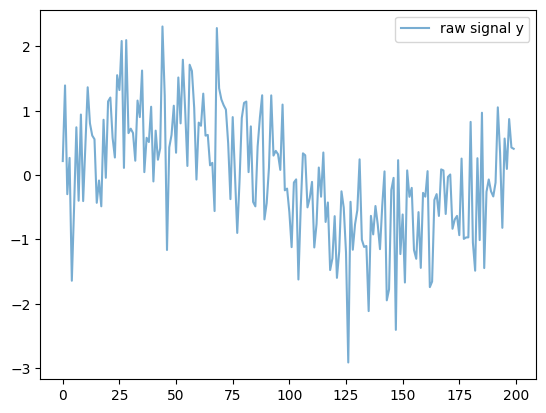

In [68]:
x = np.linspace(0, 2 * np.pi, 200)
noise = np.random.randn(len(x)) * 0.75
y = np.sin(x) + noise
plt.plot(y, label="raw signal y", alpha=0.6)
plt.legend()

## Moving Average
A moving average places a window along a signal, taking an average at that window position, and then slides the window over by one place, takes another average, and keeps going until it gets to the end of the signal. This is a nice way to smooth-out variability in a signal. 

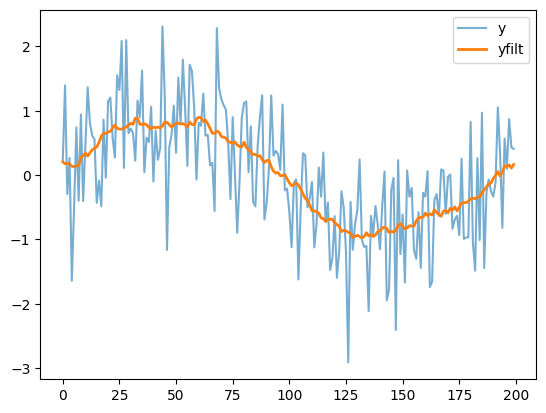

In [73]:
from scipy.ndimage import uniform_filter1d
yfilt = uniform_filter1d(y, size=100)  # The size parameter gives the width of the window that the average is taken over
plt.plot(y, label="y", alpha=0.6)
plt.plot(yfilt, label="yfilt", linewidth=2)
plt.legend()

## Quick breakout: try modifying the size parameter in the moving average. How does it change the filtered signal?

Answer: As window size increases, the data less matches the shape of the original signal and converges to the lower
  dimension.

## Median filter
A median filter is nearly identical to a moving average, except it takes the median over a window instead of the mean. This often results in better noise reduction, because median is more resilient to outliers than the mean. 

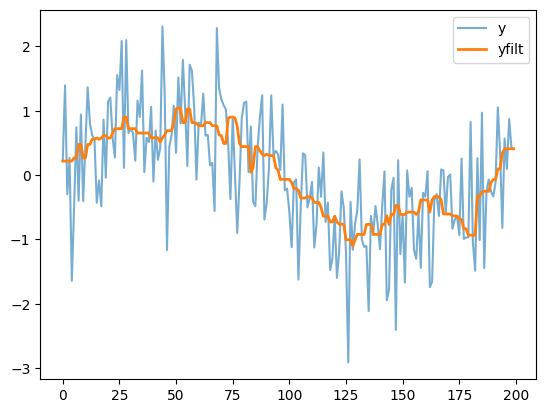

In [74]:
from scipy.ndimage import median_filter
yfilt = median_filter(y, size=15)  # The size parameter gives the width of the window that the average is taken over
plt.plot(y, label="y", alpha=0.6)
plt.plot(yfilt, label="yfilt", linewidth=2)
plt.legend()

The median filter is often used in multiple dimensions as well, particularly in image processing applications. Let's see how we can smooth this image:

In [75]:
from PIL import Image
from io import BytesIO
import requests

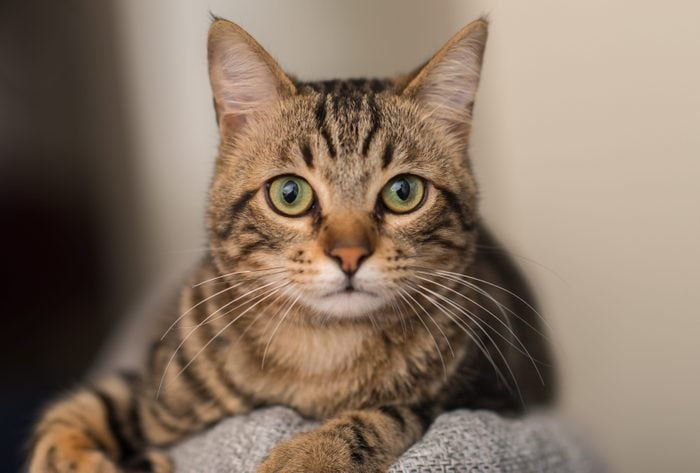

In [77]:
url = "https://github.com/galenegan/DATA-3320/blob/main/classification_data/cat.jpeg?raw=true"
response = requests.get(url)
img = Image.open(BytesIO(response.content))
img

In [81]:
img_array = np.array(img)
img_filt = median_filter(img_array, size=(15, 15, 1))

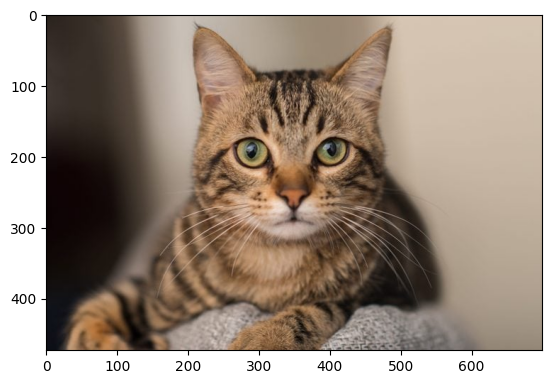

In [79]:
plt.imshow(img_array)

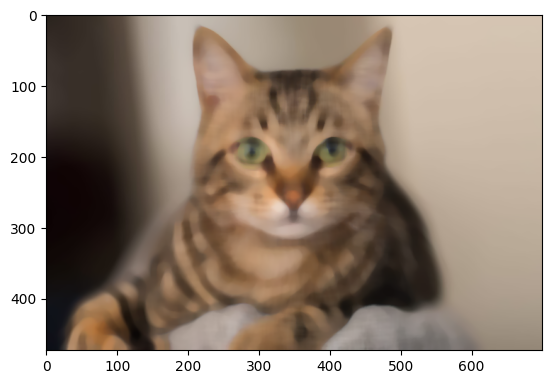

In [80]:
plt.imshow(img_filt)

# Appendix

##  Type consistency and casting
One of the most common problems you'll find with a dataset is data stored as the wrong type, e.g., strings instead of floats, floats instead of ints, etc. Before analyzing data quantitatively, it is important to make sure that all your types are correct. We'll use a modified version of the wine dataset to highlight some common problems and how to fix them.

In [82]:
df = pd.read_csv("../data/wine_types.csv")

In [83]:
df.head()

,outlier,alcohol,proline
0,1.0,"13,29",concentration = 1270.0
1,1.0,"14,3",concentration = 1280.0
2,1.0,"13,68",concentration = 990.0
3,1.0,"14,06",concentration = 1295.0
4,1.0,"14,22",concentration = 970.0


In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   outlier  129 non-null    float64
 1   alcohol  129 non-null    str    
 2   proline  129 non-null    str    
dtypes: float64(1), str(2)
memory usage: 3.2 KB


Each of the columns has at leaset one problem with it.

Let's fix the outlier column first, because it's the easiest:

In [85]:
df["outlier"] = df["outlier"].astype(int)

or...

In [86]:
df["outlier"] = df["outlier"].astype(bool)

In [87]:
df["outlier"]

0       True
1       True
2       True
3       True
4       True
       ...  
124    False
125    False
126    False
127    False
128    False
Name: outlier, Length: 129, dtype: bool

And now alcohol:

In [88]:
df["alcohol"] = df["alcohol"].str.replace(",", ".").astype(float)

In [89]:
df["alcohol"]

0      13.29
1      14.30
2      13.68
3      14.06
4      14.22
       ...  
124    13.71
125    13.40
126    13.27
127    13.17
128    14.13
Name: alcohol, Length: 129, dtype: float64

And proline:

In [90]:
df["proline"] = [float(i.split("= ")[-1]) for i in df["proline"].values]

In [91]:
df["proline"]

0      1270.0
1      1280.0
2       990.0
3      1295.0
4       970.0
        ...  
124     740.0
125     750.0
126     835.0
127     840.0
128     560.0
Name: proline, Length: 129, dtype: float64

## Log-normal distribution
Log-normal distributions arise in lots of physical scenarios where a variable is restricted to positive values. If a variable is log-normally distributed, that means that the natural log of the variable is normally-distributed. Let's look at wave height to see whether it might be log-normally distributed

In [ ]:
df["log_wave_height"] = np.log(df["wave_height"])
fig = plt.figure()
plt.hist(df["log_wave_height"], bins="auto")

Still a little skewed, but much better! Now we can more easily apply our normal distribution rules of thumb to any given value of wave height, as long as we log-transform it first. For example, we might want to do some analysis that is valid for 95% most common wave conditions. We could filter our dataframe using the 95% rule:

In [ ]:
lower_bound = df["log_wave_height"].mean() - 2 * df["log_wave_height"].std()
upper_bound = df["log_wave_height"].mean() + 2 * df["log_wave_height"].std()
condition = ((df["log_wave_height"] >= lower_bound) & (df["log_wave_height"] <= upper_bound))
df_filt = df.loc[condition]

In [ ]:
plt.hist(df_filt["log_wave_height"], bins="auto")

And plotting again in the original un-transformed space:

In [ ]:
plt.hist(df_filt["wave_height"], bins="auto")

## Breakout: Outlier identification
Load the seismic dataset contained in `seismic.arff`. About 93% of the dataset contains seismic readings that were not correlated to an eventual earthquake (`class = 0`). But the remaining rows contain data that did result in an earthquake (`class = 1`). Using visual outlier detection tools, can you isolate the rows associated with `class = 1` based on the other measured features?

In [94]:
df = pd.read_csv("../data/seismic.arff")
print(df.describe())
print(df.head())


            genergy        gpuls     gdenergy       gdpuls       nbumps  \
count  2.584000e+03  2584.000000  2584.000000  2584.000000  2584.000000   
mean   9.024252e+04   538.579334    12.375774     4.508901     0.859520   
std    2.292005e+05   562.652536    80.319051    63.166556     1.364616   
min    1.000000e+02     2.000000   -96.000000   -96.000000     0.000000   
25%    1.166000e+04   190.000000   -37.000000   -36.000000     0.000000   
50%    2.548500e+04   379.000000    -6.000000    -6.000000     0.000000   
75%    5.283250e+04   669.000000    38.000000    30.250000     1.000000   
max    2.595650e+06  4518.000000  1245.000000   838.000000     9.000000   

           nbumps2      nbumps3      nbumps4      nbumps5  nbumps6  nbumps7  \
count  2584.000000  2584.000000  2584.000000  2584.000000   2584.0   2584.0   
mean      0.393576     0.392802     0.067724     0.004644      0.0      0.0   
std       0.783772     0.769710     0.279059     0.068001      0.0      0.0   
min     

In [ ]:
# plot the data

In [ ]:
# calculate mean, std of original data

# calculate upper bound and lower bound for 2 std's

# filter for rows where

In [95]:
num_features = ['genergy', 'gpuls', 'gdenergy', 'gdpuls', 'nbumps', 'energy', 'maxenergy']

means = df[num_features].mean()
stds = df[num_features].std()

# Flag rows where any feature is > 2 std above the mean
outlier_flags = (df[num_features] > means + 2 * stds)

# Keep rows that are outliers in at least 2 features
isolated = df[outlier_flags.sum(axis=1) >= 2]

print(f"Isolated rows: {len(isolated)}")
print(f"Class 1 recall: {isolated['class'].sum()} of {df['class'].sum()} earthquake events captured")
print(isolated)

Isolated rows: 206
Class 1 recall: 29 of 170 earthquake events captured
     seismic seismicacoustic shift  genergy  gpuls  gdenergy  gdpuls ghazard  \
70         a               a     W   590510   1780        23      -6       a   
124        a               a     W   715390   1923        36      36       a   
129        a               a     W   620720   1789        17      23       a   
158        a               b     W  1049580   1807        31      21       a   
161        b               c     W   974430   1828        20      20       a   
...      ...             ...   ...      ...    ...       ...     ...     ...   
2523       b               a     W    14050    271        -3       2       a   
2549       a               a     W    76490   1203       484     367       b   
2554       a               a     W    29320    526       125     101       a   
2565       b               a     W    42640    576       264     150       a   
2579       b               a     W    81410    7